In [1]:
import sys
import os

# Adds the parent directory (root) to the Python path
sys.path.append(os.path.abspath(os.path.join('..')))


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import holidays

In [3]:
df = pd.read_parquet('../data/processed/transactions_with_segments.parquet')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,transaction_type,Segment
0,497946,37410,BLACK AND WHITE PAISLEY FLOWER MUG,19152,2010-02-15 11:57:00,0.1,13902.0,Denmark,Sale,Mega-Bulk-Tail
1,501534,21091,SET/6 WOODLAND PAPER PLATES,12960,2010-03-17 13:09:00,0.1,13902.0,Denmark,Sale,Mega-Bulk-Tail
2,501534,21099,SET/6 STRAWBERRY PAPER CUPS,12960,2010-03-17 13:09:00,0.1,13902.0,Denmark,Sale,Mega-Bulk-Tail
3,501534,21085,SET/6 WOODLAND PAPER CUPS,12744,2010-03-17 13:09:00,0.1,13902.0,Denmark,Sale,Mega-Bulk-Tail
4,501534,21092,SET/6 STRAWBERRY PAPER PLATES,12480,2010-03-17 13:09:00,0.1,13902.0,Denmark,Sale,Mega-Bulk-Tail


In [4]:
df.shape

(504731, 10)

In [5]:
Commercial_df = df[df['Segment'] == "Commercial"]
print(Commercial_df.shape[0])
print(Commercial_df["Quantity"].describe())

42027
count    42027.000000
mean        22.905085
std          3.797460
min         13.000000
25%         20.000000
50%         24.000000
75%         24.000000
max         32.000000
Name: Quantity, dtype: float64


In [6]:
# Convert InvoiceDate to datetime and set it as index for time-series modeling
df = Commercial_df.copy()
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [7]:
print(df['InvoiceDate'].max())
print(df['InvoiceDate'].min()) 

2010-12-09 19:32:00
2009-12-01 07:45:00


## Feature Engineering

### Aggregate Data to Daily Demand

In [8]:
# Convert 'InvoiceDate' to datetime and extract day from timestamp
df['InvoiceDate'] = pd.to_datetime(df["InvoiceDate"]).dt.normalize()

def aggregate_daily_demand(df):

    daily_demand = (
        df.groupby(
            ["InvoiceDate", "StockCode"],
            as_index=False
        )
        .agg(
            Quantity=("Quantity", "sum"),
            Price=("Price", "mean")
        )
    )

    return daily_demand

daily_demand_df = aggregate_daily_demand(df)

In [9]:
daily_demand_df.head()

,InvoiceDate,StockCode,Quantity,Price
0,2009-12-01,16156N,25,0.42
1,2009-12-01,16156S,25,0.42
2,2009-12-01,16161P,25,0.42
3,2009-12-01,16161U,25,0.42
4,2009-12-01,16169C,50,0.42


In [10]:
daily_demand_df.shape

(33595, 4)

I will use the functions I have already written in features subfolder

In [11]:
from features.calendars import create_calendar_features
from features.easter_christmas import create_christmas_features
from features.holidays import create_holiday_features
from features.lag_features import create_lag_features
from features.momentum import create_momentum_features
from features.rolling import create_rolling_features
from features.sku_features import create_sku_features
from features.create_target import create_target
from features.product_lifecycle import create_product_lifecycle_features
from features.feature_pipeline import build_demand_features

In [12]:
import subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "pyyaml"])

0

In [13]:
import pydantic
from config.feature_config import (DATE_COL, 
                                   TARGET_COL, 
                                   PRICE_COL, 
                                   PRODUCT_COL,
                                   DROP_COLS
)

In [14]:
print(DATE_COL)
print(PRICE_COL)

InvoiceDate
Price


In [15]:

demand_features = build_demand_features(daily_demand_df)

In [16]:
demand_features.head()

,InvoiceDate,StockCode,Quantity,Price,price_ratio,day_of_week,day_of_month,week_of_year,month,quarter,...,rolling_mean_28,rolling_std_28,momentum_7_28,momentum_14_28,sku_mean_qty,sku_median_qty,sku_std_qty,sku_avg_price,sku_cv,target
0,2009-12-01,16156N,25,0.42,1.000000,1,1,49,12,4,...,NaN,NaN,NaN,NaN,30.113636,25.0,11.538038,0.420000,0.383150,3.258097
1,2009-12-01,16156S,25,0.42,1.000644,1,1,49,12,4,...,NaN,NaN,NaN,NaN,37.837838,25.0,20.923916,0.419730,0.552989,3.258097
2,2009-12-01,16161P,25,0.42,1.000414,1,1,49,12,4,...,NaN,NaN,NaN,NaN,38.260870,25.0,18.532138,0.419826,0.484363,3.258097
3,2009-12-01,16161U,25,0.42,1.001913,1,1,49,12,4,...,NaN,NaN,NaN,NaN,31.954887,25.0,12.819176,0.419198,0.401165,3.258097
4,2009-12-01,16169C,50,0.42,1.000000,1,1,49,12,4,...,NaN,NaN,NaN,NaN,33.035714,25.0,16.740906,0.420000,0.506752,3.931826


In [17]:
# Did the item sell at all yesterday?
demand_features["was_active_yesterday"] = (demand_features["lag_1"] > 0).astype(int)

In [18]:
demand_features.shape

(33595, 41)

In [19]:
demand_features['StockCode'].nunique()

2448

In [20]:
demand_features['InvoiceDate'].max()

Timestamp('2010-12-09 00:00:00')

## Build and Train LIGHTGBM Model

In [21]:
# timebased train-valid split
def train_valid_split(
    df,
    date_col,
    split_date
):

    train_df = df[
        df[date_col] < split_date
    ]

    valid_df = df[
        df[date_col] >= split_date
    ]

    return train_df, valid_df

# split the features
train_df, valid_df = train_valid_split(
    demand_features,
    date_col='InvoiceDate',
    split_date='2010-10-01'
)

print(f"Train shape: {train_df.shape}")
print(f"Valid shape: {valid_df.shape}")

Train shape: (23905, 41)
Valid shape: (9690, 41)


In [22]:
import joblib
from lightgbm import LGBMRegressor
import lightgbm as lgb
from sklearn.metrics import (mean_squared_error, 
                             mean_absolute_error, 
                             mean_absolute_percentage_error)

# model parameters
params = {
    'objective': "regression",
    'metric': "rmse",
    #'num_leaves': 31,
    'boosting_type': "gbdt",
    'learning_rate': 0.05,
     'n_estimators': 600,
     'colsample_bytree': 0.8,
     'subsample': 0.8,
     'random_state': 42
}

In [23]:
X_train = train_df.drop(columns = DROP_COLS, errors = "ignore")
y_train = train_df[TARGET_COL]

X_test = valid_df.drop(columns =DROP_COLS, errors = "ignore")
y_test = valid_df[TARGET_COL]   

In [24]:
X_train.columns

Index(['Price', 'price_ratio', 'day_of_week', 'day_of_month', 'week_of_year',
       'month', 'quarter', 'is_weekend', 'days_to_christmas',
       'christmas_window', 'christmas_countdown', 'days_to_easter',
       'easter_window', 'is_holiday', 'holiday_name', 'days_to_next_holiday',
       'days_since_previous_holiday', 'days_since_first_sale', 'lag_1',
       'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_std_7',
       'rolling_mean_14', 'rolling_std_14', 'rolling_mean_28',
       'rolling_std_28', 'momentum_7_28', 'momentum_14_28', 'sku_mean_qty',
       'sku_median_qty', 'sku_std_qty', 'sku_avg_price', 'sku_cv',
       'was_active_yesterday'],
      dtype='str')

In [25]:
# Define your categorical features from your config
categorical_cols = ["holiday_name"]

# create LightGBM datasets
train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_cols,)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data,
                        categorical_feature=categorical_cols,)

In [26]:
#Train the model
model = lgb.train(params, train_data, num_boost_round=1000, 
                  valid_sets=[test_data], callbacks=[lgb.early_stopping(stopping_rounds=50)])


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001738 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5243
[LightGBM] [Info] Number of data points in the train set: 23905, number of used features: 34
[LightGBM] [Info] Start training from score 28.478310
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[40]	valid_0's rmse: 13.8613


In [27]:
# make predictions
predictions = model.predict(X_test)

## Evaluation

In [28]:
from models.evaluate import evaluate, wmape_sklearn, weighted_mape

evaluate(y_true = y_test, y_pred = predictions)

{'MAE': 8.466632901978688,
 'RMSE': 13.861304753036055,
 'wmape_sklearn': np.float64(0.2910744872246787),
 'WMAPE': np.float64(0.29107448722467866)}

## Feature Importance

Plot the feature importance to see what drove these predictions

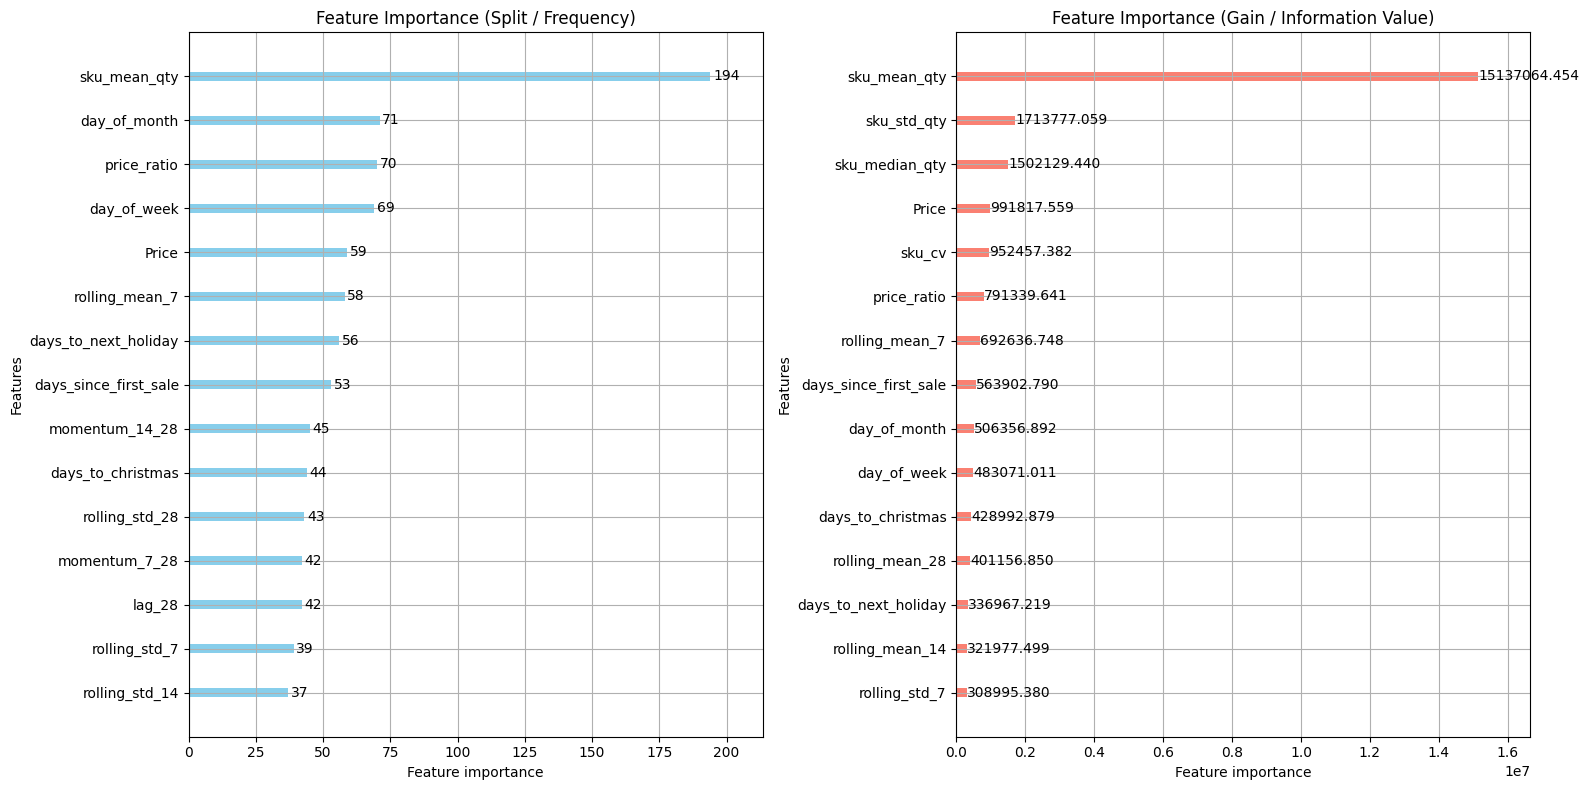

In [29]:
import matplotlib.pyplot as plt

# Configure a side-by-side plotting area
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

# Plot Split Importance (Frequency of use)
lgb.plot_importance(
    model, 
    importance_type="split", 
    max_num_features=15, 
    ax=ax[0], 
    title="Feature Importance (Split / Frequency)",
    color="skyblue"
)

# Plot Gain Importance (Contribution to accuracy)
lgb.plot_importance(
    model, 
    importance_type="gain", 
    max_num_features=15, 
    ax=ax[1], 
    title="Feature Importance (Gain / Information Value)",
    color="salmon"
)

plt.tight_layout()
plt.show()


## Loss Function Adjustment

By default, LightGBM optimizes for RMSE (objective: 'regression'). I want the model to focus less on penalizing these extreme outliers and instead optimize for overall percentage accuracy. Therefore, I change LightGBM objective parameter

In [30]:
# Update parameters to fix underfitting
params = {
    "objective": "tweedie",  
    "metric": "rmse",
    "tweedie_variance_power": 1.5,  # 1.5 is standard for retail sales
    "learning_rate": 0.01,
    "num_leaves": 63,
}

# Run training with more boosting rounds
model = lgb.train(
    params,
    train_data,
    num_boost_round=2000,
    valid_sets=[test_data],
    callbacks=[lgb.early_stopping(stopping_rounds=150)],
)

# make predictions
predictions = model.predict(X_test)

# evaluate
print("\n")
print("Eval metrics")

evaluate(y_true = y_test, y_pred = predictions)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002861 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5243
[LightGBM] [Info] Number of data points in the train set: 23905, number of used features: 34
[LightGBM] [Info] Start training from score 3.349143
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[236]	valid_0's rmse: 13.9274


Eval metrics


{'MAE': 8.433256389936476,
 'RMSE': 13.927444860523462,
 'wmape_sklearn': np.float64(0.289927035665067),
 'WMAPE': np.float64(0.289927035665067)}

In [31]:
# Update training parameters to handle outliers better
params = {
    'objective': "huber",
    'metric': "rmse",
    #'num_leaves': 31,
    #'boosting_type': "gbdt",
    'learning_rate': 0.045,
     'n_estimators': 500,
     #'colsample_bytree': 0.8,
     #'subsample': 0.8,
     'random_state': 42,
     'verbosity': 0
}

#Train the model
model = lgb.train(params, train_data, num_boost_round=1000, 
                  valid_sets=[test_data], callbacks=[lgb.early_stopping(stopping_rounds=50)])

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[114]	valid_0's rmse: 15.9642


In [32]:
# make predictions
predictions = model.predict(X_test)
evaluate(y_true = y_test, y_pred = predictions)

{'MAE': 8.262392694523184,
 'RMSE': 15.964187366770098,
 'wmape_sklearn': np.float64(0.2840529103659632),
 'WMAPE': np.float64(0.28405291036596314)}

Adjusting objective to Huber loss improved weighted mape by only a tiny fraction

## Log Transform Target

In [33]:
# log transform target
y_train_log = np.log1p(train_df[TARGET_COL])
y_test_log = valid_df[TARGET_COL] 

# create train data with log target
# create LightGBM datasets
train_data = lgb.Dataset(X_train, label=y_train_log, categorical_feature=categorical_cols,)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data,
                        categorical_feature=categorical_cols,)

In [34]:
# Train model using y_train_log with regression
# model parameters
params1 = {
    'objective': "regression",
    'metric': "rmse",
    #'num_leaves': 31,
    'boosting_type': "gbdt",
    'learning_rate': 0.05,
     'n_estimators': 600,
     'colsample_bytree': 0.8,
     'subsample': 0.8,
     'random_state': 42
}

model = lgb.train(params1, train_data, num_boost_round=1000, 
                  valid_sets=[test_data], 
                  callbacks=[lgb.early_stopping(stopping_rounds=50)])

# Inverse transform predictions before evaluating
log_predictions = model.predict(X_test)
final_predictions = np.expm1(log_predictions)

# evaluate
print("\n")
print("Eval metrics")

evaluate(y_true = y_test, y_pred = final_predictions)

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[219]	valid_0's rmse: 30.4661


Eval metrics


{'MAE': 7.823160954129468,
 'RMSE': 13.984248234026886,
 'wmape_sklearn': np.float64(0.26895255641321003),
 'WMAPE': np.float64(0.26895255641321003)}

Log transforming the target reduced weighted MAPE from 29.1 to 26.9%

### Plot feature importance again

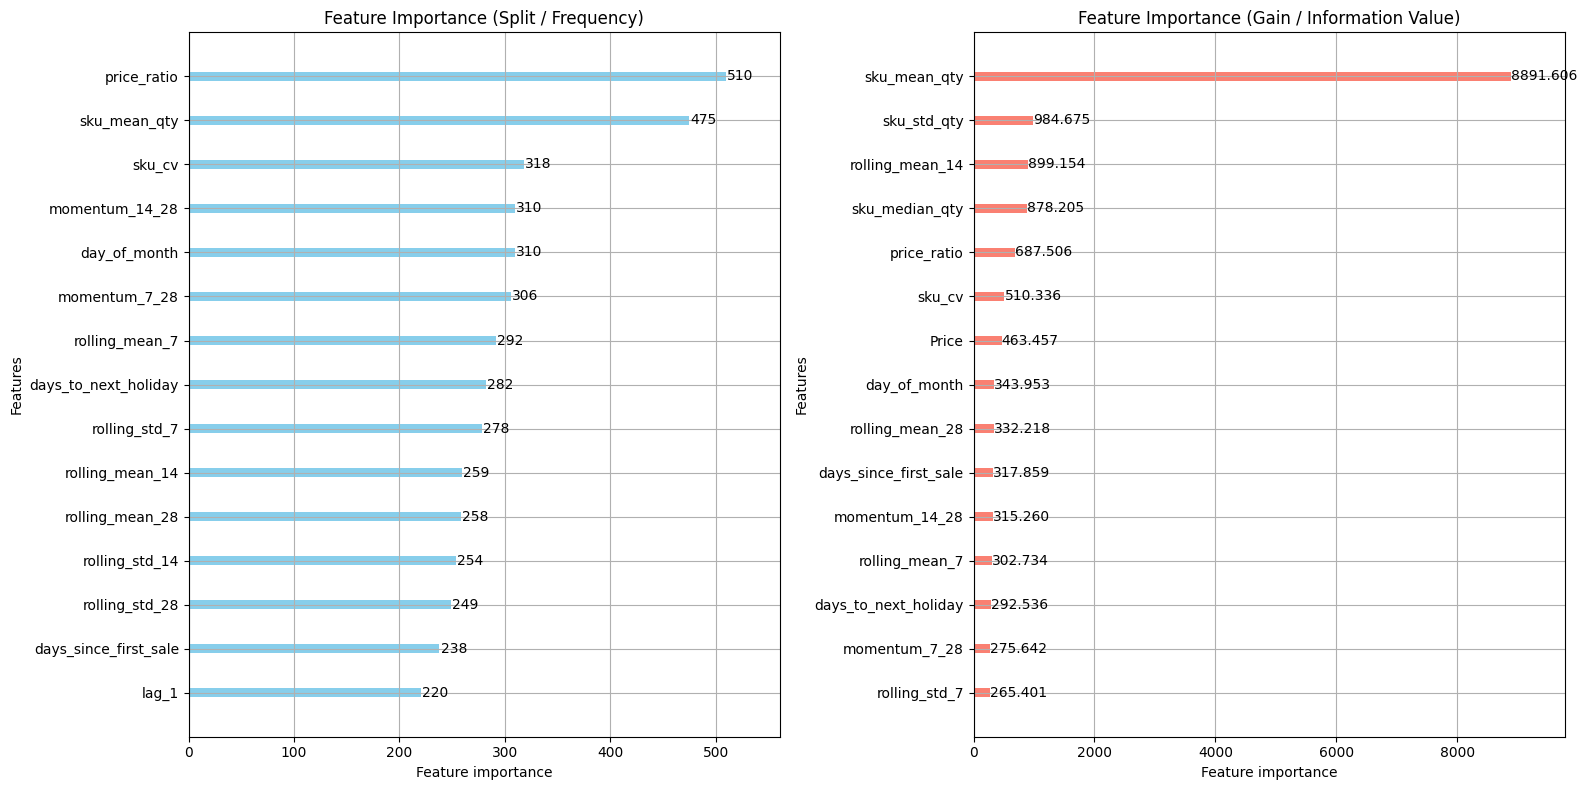

In [35]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

# Plot Split Importance (Frequency of use)
lgb.plot_importance(
    model, 
    importance_type="split", 
    max_num_features=15, 
    ax=ax[0], 
    title="Feature Importance (Split / Frequency)",
    color="skyblue"
)

# Plot Gain Importance (Contribution to accuracy)
lgb.plot_importance(
    model, 
    importance_type="gain", 
    max_num_features=15, 
    ax=ax[1], 
    title="Feature Importance (Gain / Information Value)",
    color="salmon"
)

plt.tight_layout()
plt.show()


### Top 10 features for split

1. Price ratio (510)
2. SKU mean quantity (475)
3. SKU coefficient of variation (318)
4. Momentum_14_28 (310)
5. Day of month (310)
6. Momentum_7_28 (306)
7. Rolling mean 7 (292)
8. Days to next holiday (282)
9. Rolling std 7 (278)
10. Rolling mean 14 (259)

### Top 10 features for gain

1. SKU mean quantity (8,891)
2. SKU std quantity (984)
3. Rolling mean 14 (899)
4. SKU median quantity (878)
5. Price ratio (687)
6. SKU coefficient of variation (510)
7. Price (463)
8. Day of month (343)
9. Rolling mean 28 (332)
10. Day since first sale (317)

In [36]:
# Merge predictions directly back into test_df
test_df = valid_df.copy()
test_df["predicted_demand"] = predictions

# rename target column for clarity during aggregation
test_df = test_df.rename(columns={"Quantity": "actual_demand"})

# verify the alignment side-by-side
print(test_df[["InvoiceDate", "StockCode", "actual_demand", "predicted_demand"]].head())

      InvoiceDate StockCode  actual_demand  predicted_demand
23905  2010-10-01     11001             16         25.568547
23906  2010-10-01     16048             24         24.310231
23907  2010-10-01    16161P             25         26.672955
23908  2010-10-01     20668             48         26.667013
23909  2010-10-01     20724             20         27.058698


In [37]:
#create weekly timestamp
test_df["week"] = test_df["InvoiceDate"].dt.to_period("W")

# aggregate weekly
weekly_df = (
    test_df.groupby(["week"])[["actual_demand", "predicted_demand"]].sum().reset_index()
)

# Calculate WMAPE on the weekly aggregation
weekly_wmape = weighted_mape(weekly_df["actual_demand"], weekly_df["predicted_demand"])
print(f"Weekly Aggregated WMAPE for Commercial segment: {weekly_wmape:.2%}")

Weekly Aggregated WMAPE for Commercial segment: 10.79%


## Forecast Bias

Is the model over-forecasting or under-forecasting?

forecast bias = (sum of (forecast - actual) / sum of actual) x 100

In [39]:
# Formula: sum(Forecast - Actual) / sum(Actual) * 100
bias_fo = (test_df['predicted_demand'] - test_df['actual_demand']).sum() / test_df['actual_demand'].sum() * 100
bias_alt = (test_df['predicted_demand'].sum() - test_df['actual_demand'].sum()) / test_df['actual_demand'].sum() * 100

print(f"Model bias: {bias_fo:.2f}%")
print(f"Alt result: {bias_alt:.2f}%")

Model bias: -10.79%
Alt result: -10.79%
